**Task 1 — Funnel & cohort analysis**


The goal of this section is to understand where users drop off during onboarding, how retention varies across cohorts, and which early behaviours appear most correlated with long-term engagement.


In [3]:
# Core libraries for analysis and visualisation libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup successful")
pd.set_option('display.max_columns', None)

Setup successful


In [4]:
# Load user-level and event-level datasets
users = pd.read_csv('quin_users.csv')
events = pd.read_csv('quin_events.csv')


We will first inspect the shape, schema, and sample records from both datasets to understand the available user attributes and event structure before building any metrics.


In [5]:
# Preview datasets
print("Users Shape:", users.shape)
print("Events Shape:", events.shape)

display(users.head())
display(events.head())


Users Shape: (2000, 6)
Events Shape: (37051, 6)


,user_id,signup_date,acquisition_src,device_model,country,plan_type
0,u4b4b26ab73,2024-09-15,organic,Quin Mk2,GB,free
1,u747eaac743,2024-09-15,paid_social,Quin Mk3,GB,free
2,u5d7de26505,2024-09-17,referral,Quin Mk3,GB,free
3,u925fb90cbd,2024-09-17,app_store,Quin Mk3 Pro,DE,free
4,ub049b327bb,2024-09-12,app_store,Quin Mk3 Pro,GB,free


,event_id,user_id,event_name,event_ts,session_id,properties
0,ed5d933cbfd,u3c6d544afb,account_created,2024-09-01 00:02:00,s3000d1ff57,{}
1,e8e3cf3f211,uf14bc6d99f,account_created,2024-09-01 00:03:00,sa13bc45e86,{}
2,e60799142bb,u17a56e379d,account_created,2024-09-01 00:04:00,s521823b5be,{}
3,e5cc6a34c2c,uc67e9b1f49,account_created,2024-09-01 00:04:00,s93d770328f,{}
4,e998dca15d7,u0c4bfbaaa1,account_created,2024-09-01 00:04:00,sae82964f66,{}


In [6]:
# Check column types
print(users.info())
print(events.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   user_id          2000 non-null   object
 1   signup_date      2000 non-null   object
 2   acquisition_src  2000 non-null   object
 3   device_model     2000 non-null   object
 4   country          2000 non-null   object
 5   plan_type        2000 non-null   object
dtypes: object(6)
memory usage: 93.9+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37051 entries, 0 to 37050
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   event_id    37051 non-null  object
 1   user_id     37051 non-null  object
 2   event_name  37051 non-null  object
 3   event_ts    37051 non-null  object
 4   session_id  37051 non-null  object
 5   properties  37051 non-null  object
dtypes: object(6)
memory usage: 1.7+ MB
None


Before moving into funnel analysis, we will first check for missing values and obvious schema issues that could affect event aggregation or cohort calculations.

In [7]:
# Missing values
print(users.isnull().sum())
print(events.isnull().sum())

user_id            0
signup_date        0
acquisition_src    0
device_model       0
country            0
plan_type          0
dtype: int64
event_id      0
user_id       0
event_name    0
event_ts      0
session_id    0
properties    0
dtype: int64


The datasets is found to be clean overall, with no missing values that could have potentially affected the core onboarding or engagement events used in the analysis.

As a next step, we will now review the overall event distribution to get a quick sense of which user actions/events are most common

In [8]:
# Event distribution
events['event_name'].value_counts()

,count
event_name,
app_opened,19695
ride_tracked,6220
push_notification_received,2732
app_install,2000
account_created,1830
device_paired,1312
emergency_contact_added,1152
first_ride_tracked,1015
sos_test_triggered,231


### Data Validation Check

Before building the onboarding funnel, we will check whether onboarding milestone events occurred multiple times for the same user. For instance, if there are two first_ride_tracked for same user ID. This is just a cautionary step to ensure we have clean data

In [9]:
# Count duplicate onboarding events per user

onboarding_events = [
    'app_install',
    'account_created',
    'device_paired',
    'emergency_contact_added',
    'first_ride_tracked'
]

duplicate_check = (
    events[events['event_name'].isin(onboarding_events)]
    .groupby(['user_id', 'event_name'])
    .size()
    .reset_index(name='count')
)

# Show cases where same user triggered same onboarding event multiple times
duplicates = duplicate_check[duplicate_check['count'] > 1]

print("Duplicate onboarding event records:")
display(duplicates.head(20))

print("Total duplicate rows:", duplicates.shape[0])

Duplicate onboarding event records:


,user_id,event_name,count


Total duplicate rows: 0


No duplicate onboarding milestone events were found, meaning each onboarding step can be treated as a unique user-level milestone without additional deduplication logic.

In [10]:
# Convert dates to datetime

users['signup_date'] = pd.to_datetime(users['signup_date'])
events['event_ts'] = pd.to_datetime(events['event_ts'])

print(users.dtypes)
print(events.dtypes)

user_id                    object
signup_date        datetime64[ns]
acquisition_src            object
device_model               object
country                    object
plan_type                  object
dtype: object
event_id              object
user_id               object
event_name            object
event_ts      datetime64[ns]
session_id            object
properties            object
dtype: object


### Event Ordering Caveat

During exploratory analysis, some onboarding events appeared slightly out of chronological order (e.g., `account_created` before `app_install`). This likely reflects instrumentation latency common in mobile analytics systems.

On manually checking for first user: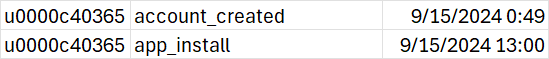

To avoid assumptions around exact ordering, we will conduct onboarding analysis based on event sequence as was provided in Quin's Assessment PDF.

In [11]:
# Create event sequence per user

event_order = (
    events.sort_values(['user_id', 'event_ts'])
    .groupby('user_id')['event_name']
    .apply(list)
)

# Preview a few user journeys
event_order.head(10)

,event_name
user_id,
u0000c40365,"[account_created, app_install, app_opened, eme..."
u000aa3721f,"[account_created, device_paired, app_install, ..."
u000efe5098,"[account_created, app_install, push_notificati..."
u0035dcdd94,"[account_created, app_install]"
u0059299933,"[account_created, app_install, emergency_conta..."
u005d8fc543,"[account_created, app_install, device_paired, ..."
u0070c96a7f,"[account_created, app_install, device_paired, ..."
u008d4c2a22,"[account_created, app_install, device_paired, ..."
u00a0e814d7,"[account_created, app_install, app_opened, app..."


# Funnel Analysis Insights

In [12]:
# Define onboarding funnel steps

funnel_steps = [
    'app_install',
    'account_created',
    'device_paired',
    'emergency_contact_added',
    'first_ride_tracked'
]

# Build funnel table

funnel_data = []

total_users = users['user_id'].nunique()

for step in funnel_steps:
    step_users = events[events['event_name'] == step]['user_id'].nunique()

    funnel_data.append({
        'step': step,
        'users': step_users,
        'conversion_rate': round(step_users / total_users * 100, 2)
    })

funnel_df = pd.DataFrame(funnel_data)

display(funnel_df)

,step,users,conversion_rate
0,app_install,2000,100.00
1,account_created,1830,91.50
2,device_paired,1312,65.60
3,emergency_contact_added,1152,57.60
4,first_ride_tracked,1015,50.75


The largest drop-off occurs between `account_created` and `device_paired`, where roughly 28% of users do not progress further in onboarding. This suggests the device pairing step may be introducing friction early in the user journey.

The funnel also shows that while most users successfully create an account after installing the app, only around half of users reach the `first_ride_tracked` milestone. Since first ride completion is likely the closest proxy to the product’s “aha moment”, improving activation beyond onboarding appears to be an important growth opportunity.

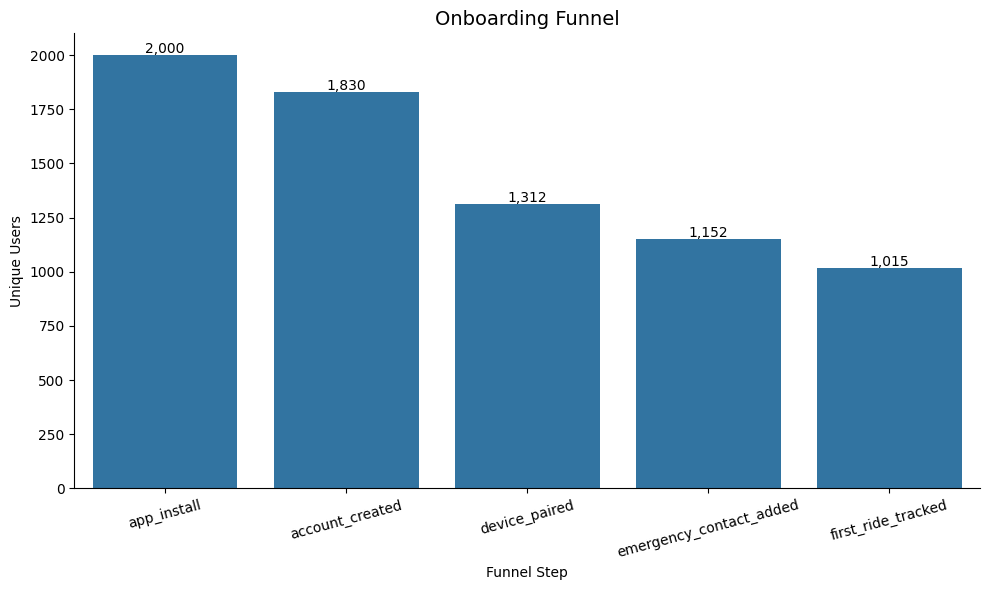

In [13]:
# Funnel chart
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=funnel_df,
    x='step',
    y='users'
)

# Add data labels
for i, value in enumerate(funnel_df['users']):
    ax.text(
        i,
        value + 10,
        f'{value:,}',
        ha='center',
        fontsize=10
    )

plt.title('Onboarding Funnel', fontsize=14)
plt.xlabel('Funnel Step')
plt.ylabel('Unique Users')

plt.xticks(rotation=15)

sns.despine()

plt.tight_layout()
plt.show()

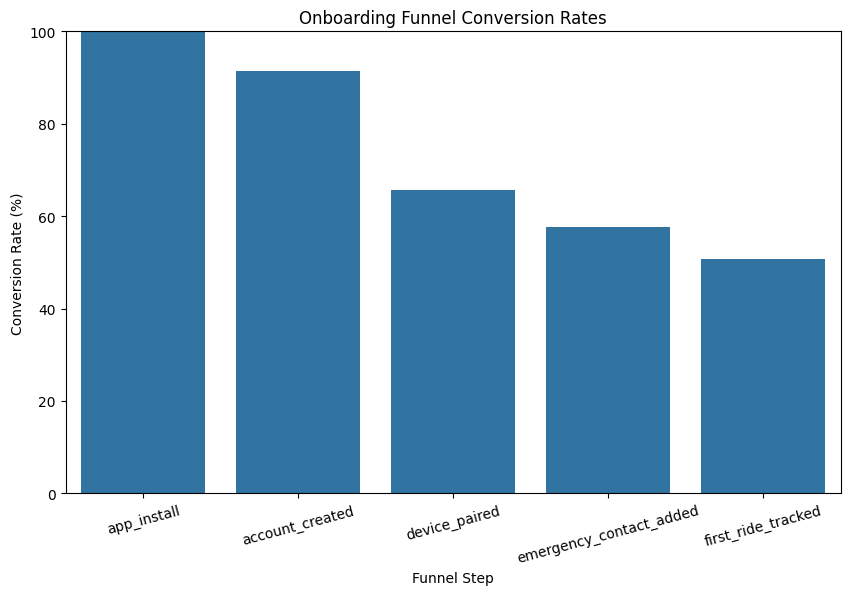

In [14]:
# Conversion percentage chart

plt.figure(figsize=(10,6))

sns.barplot(
    data=funnel_df,
    x='step',
    y='conversion_rate'
)

plt.title('Onboarding Funnel Conversion Rates')
plt.xlabel('Funnel Step')
plt.ylabel('Conversion Rate (%)')

plt.ylim(0, 100)

plt.xticks(rotation=15)

plt.show()

### Funnel Performance by Acquisition Source

After Funnel Analysis overall, it would be also interesting to check whether onboarding conversion differed meaningfully across acquisition sources. If some channels bring in users who activate more successfully than others, that can influence both acquisition strategy and onboarding prioritisation.

So as a next step, we will see the funnel conversion by acqstn source

In [15]:
# Funnel conversion by acquisition source

# Merge acquisition source into events data
events_users = events.merge(
    users[['user_id', 'acquisition_src']],
    on='user_id',
    how='left'
)

# Define funnel steps
funnel_steps = [
    'app_install',
    'account_created',
    'device_paired',
    'emergency_contact_added',
    'first_ride_tracked'
]

# Build segmented funnel table
funnel_by_source = []

for source in events_users['acquisition_src'].unique():

    source_data = events_users[
        events_users['acquisition_src'] == source
    ]

    total_users = source_data['user_id'].nunique()

    for step in funnel_steps:

        users_at_step = source_data[
            source_data['event_name'] == step
        ]['user_id'].nunique()

        funnel_by_source.append({
            'acquisition_src': source,
            'step': step,
            'users': users_at_step,
            'conversion_rate': round(users_at_step / total_users * 100, 2)
        })

funnel_by_source_df = pd.DataFrame(funnel_by_source)

display(funnel_by_source_df.head(20))

,acquisition_src,step,users,conversion_rate
0,organic,app_install,784,100.00
1,organic,account_created,712,90.82
2,organic,device_paired,511,65.18
3,organic,emergency_contact_added,437,55.74
4,organic,first_ride_tracked,405,51.66
5,paid_social,app_install,589,100.00
6,paid_social,account_created,539,91.51
7,paid_social,device_paired,376,63.84
8,paid_social,emergency_contact_added,327,55.52
9,paid_social,first_ride_tracked,298,50.59



Result - The largest onboarding drop-off (`account_created → device_paired`) was consistent across all acquisition channels, suggesting the issue is likely rooted in onboarding or product experience rather than acquisition quality alone.

Referral users demonstrated slightly stronger onboarding completion rates, particularly for device pairing and emergency contact setup. This may indicate higher initial trust or stronger product understanding among referred users.

App Store users showed the weakest activation outcomes, with the lowest percentage of users reaching the `first_ride_tracked` milestone.

## Retention Analysis

After evaluating onboarding conversion, we will now be looking at user retention to understand how engagement changed over time after signup.

For this analysis, I have defined retention as as whether a user returned to the app and generated an `app_opened` event after account creation. Same-day activity was excluded so that retention reflected genuine return behaviour rather than onboarding activity during the initial session.

This way, we will be now evaluating retention across 7-day, 30-day, and 90-day windows, and then compared retention patterns across acquisition cohorts and early user behaviours.

In [16]:
# Get account creation date per user

account_created = (
    events[events['event_name'] == 'account_created']
    .groupby('user_id')['event_ts']
    .min()
    .reset_index()
)

account_created.columns = ['user_id', 'account_created_ts']

display(account_created.head())

,user_id,account_created_ts
0,u0000c40365,2024-09-15 00:49:00
1,u000aa3721f,2024-09-11 01:22:00
2,u000efe5098,2024-09-03 01:36:00
3,u0035dcdd94,2024-09-16 00:37:00
4,u0059299933,2024-09-21 01:39:00


In [17]:
# Get app_opened events

app_opens = events[
    events['event_name'] == 'app_opened'
][['user_id', 'event_ts']]

display(app_opens.head())

,user_id,event_ts
88,uc78e801777,2024-09-01 07:00:00
92,u7e01d52e1f,2024-09-01 08:00:00
114,ud8a67f0852,2024-09-01 10:00:00
118,u9dcd2c85bc,2024-09-01 10:00:00
131,ud94d4617cd,2024-09-01 12:00:00


In [18]:
# Merge signup date with app opens

retention_df = app_opens.merge(
    account_created,
    on='user_id',
    how='left'
)

# Calculate days since account creation

retention_df['days_since_signup'] = (
    retention_df['event_ts'] - retention_df['account_created_ts']
).dt.days

display(retention_df.head())

,user_id,event_ts,account_created_ts,days_since_signup
0,uc78e801777,2024-09-01 07:00:00,2024-09-01 01:23:00,0
1,u7e01d52e1f,2024-09-01 08:00:00,2024-09-01 00:20:00,0
2,ud8a67f0852,2024-09-01 10:00:00,2024-09-01 01:50:00,0
3,u9dcd2c85bc,2024-09-01 10:00:00,2024-09-01 01:15:00,0
4,ud94d4617cd,2024-09-01 12:00:00,2024-09-01 01:55:00,0


In [19]:
# Exclude same-day app opens

retention_df = retention_df[
    retention_df['days_since_signup'] > 0
]

display(retention_df.head())

,user_id,event_ts,account_created_ts,days_since_signup
28,u88a4461707,2024-09-02 07:00:00,2024-09-01 01:12:00,1
29,u79e0ca8a4e,2024-09-02 08:00:00,2024-09-01 01:14:00,1
30,u93728f381f,2024-09-02 09:00:00,2024-09-01 01:35:00,1
33,ucabc3425ef,2024-09-02 10:00:00,2024-09-01 01:25:00,1
35,u6b267629b2,2024-09-02 10:00:00,2024-09-01 00:17:00,1


In [20]:
# Create retention summary

retention_summary = account_created.copy()

# Day 7 retention
day7_users = retention_df[
    retention_df['days_since_signup'] >= 7
]['user_id'].unique()

# Day 30 retention
day30_users = retention_df[
    retention_df['days_since_signup'] >= 30
]['user_id'].unique()

# Day 90 retention
day90_users = retention_df[
    retention_df['days_since_signup'] >= 90
]['user_id'].unique()

# Create retention columns
retention_summary['retained_7d'] = retention_summary['user_id'].isin(day7_users)
retention_summary['retained_30d'] = retention_summary['user_id'].isin(day30_users)
retention_summary['retained_90d'] = retention_summary['user_id'].isin(day90_users)

display(retention_summary.head())

,user_id,account_created_ts,retained_7d,retained_30d,retained_90d
0,u0000c40365,2024-09-15 00:49:00,True,True,False
1,u000aa3721f,2024-09-11 01:22:00,True,True,False
2,u000efe5098,2024-09-03 01:36:00,True,True,False
3,u0035dcdd94,2024-09-16 00:37:00,False,False,False
4,u0059299933,2024-09-21 01:39:00,True,True,False


,Retention Window,Retention Rate (%)
0,7-Day,77.54
1,30-Day,38.31
2,90-Day,0.00


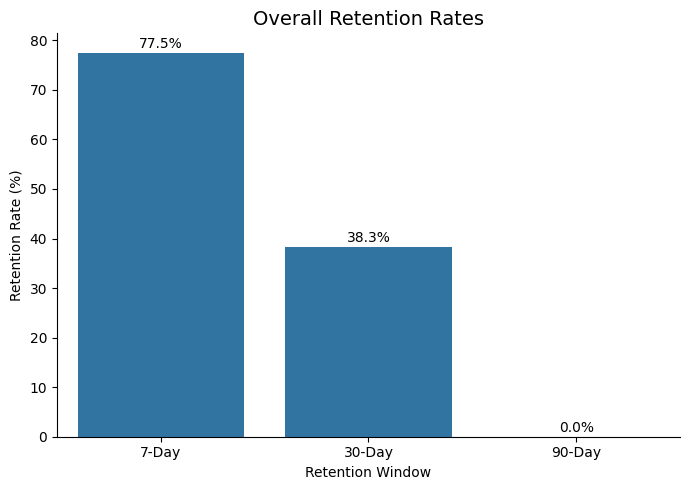

In [21]:
# Overall retention rates

overall_retention = pd.DataFrame({
    'Retention Window': ['7-Day', '30-Day', '90-Day'],
    'Retention Rate (%)': [
        round(retention_summary['retained_7d'].mean() * 100, 2),
        round(retention_summary['retained_30d'].mean() * 100, 2),
        round(retention_summary['retained_90d'].mean() * 100, 2)
    ]
})

display(overall_retention)


# Overall retention rate chart

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=overall_retention,
    x='Retention Window',
    y='Retention Rate (%)'
)

# Add data labels
for i, value in enumerate(overall_retention['Retention Rate (%)']):
    ax.text(
        i,
        value + 1,
        f'{value:.1f}%',
        ha='center',
        fontsize=10
    )

plt.title('Overall Retention Rates', fontsize=14)
plt.xlabel('Retention Window')
plt.ylabel('Retention Rate (%)')

sns.despine()

plt.tight_layout()
plt.show()

The retention curves show a meaningful decline between Day 7 and Day 30, which is fairly typical for consumer mobile products where many users initially explore the product but do not develop consistent usage habits.

This also suggests a potential opportunity for lifecycle interventions during this period. For example, targeted push notifications, onboarding nudges, or ride-related engagement campaigns between Day 7 and Day 30 may help improve habit formation and long-term retention.

The dataset only covers an 89-day observation window, which is why the 90-day retention values are either incomplete or unavailable for signup cohorts.

In [22]:
# Add acquisition source to retention summary

retention_summary = retention_summary.merge(
    users[['user_id', 'acquisition_src']],
    on='user_id',
    how='left'
)

# Calculate retention by acquisition source

retention_by_source = retention_summary.groupby(
    'acquisition_src'
).agg({
    'retained_7d': 'mean',
    'retained_30d': 'mean',
    'retained_90d': 'mean'
}).reset_index()

# Convert to percentages

retention_by_source['retained_7d'] = (
    retention_by_source['retained_7d'] * 100
).round(2)

retention_by_source['retained_30d'] = (
    retention_by_source['retained_30d'] * 100
).round(2)

retention_by_source['retained_90d'] = (
    retention_by_source['retained_90d'] * 100
).round(2)

# Rename columns

retention_by_source.columns = [
    'Acquisition Source',
    '7-Day Retention',
    '30-Day Retention',
    '90-Day Retention'
]

display(retention_by_source)

,Acquisition Source,7-Day Retention,30-Day Retention,90-Day Retention
0,app_store,81.78,36.02,0.0
1,organic,77.39,44.66,0.0
2,paid_social,74.95,29.50,0.0
3,referral,79.01,40.52,0.0


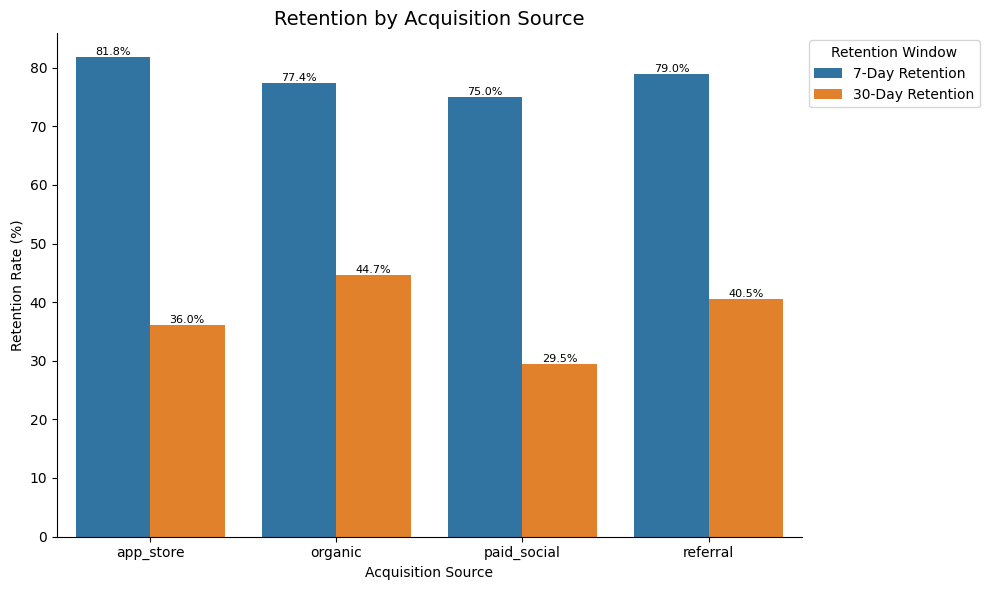

In [23]:
# Reshape data for plotting

retention_plot = retention_by_source.melt(
    id_vars='Acquisition Source',
    value_vars=[
        '7-Day Retention',
        '30-Day Retention'
    ],
    var_name='Retention Window',
    value_name='Retention Rate'
)

# Plot grouped retention chart

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=retention_plot,
    x='Acquisition Source',
    y='Retention Rate',
    hue='Retention Window'
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8)

plt.title('Retention by Acquisition Source', fontsize=14)
plt.xlabel('Acquisition Source')
plt.ylabel('Retention Rate (%)')

plt.legend(
    title='Retention Window',
    bbox_to_anchor=(1, 1),
    loc='upper left'
)

sns.despine()

plt.tight_layout()
plt.show()

Retention rates also varied across acquisition cohorts. Organic users showed the strongest 30-day retention 44.7%, followed by referral users 40.5%, while paid social users retained at a lower rate 29.5%. This suggests that acquisition quality may differ by channel, with organic and referral cohorts potentially bringing in users with stronger initial intent or better product fit. Based on these findings, we could prioritise retention-focused onboarding and lifecycle interventions for lower-retention cohorts, particularly users acquired through paid channels.

In [24]:
# Check maximum observed user age

print(retention_df['days_since_signup'].max())

89


### Behaviours in the first 7 days predict long-term retention

To identify early behavioural signals associated with retention, we will need to keep the analysis to user activity occurring within the first 7 days after signup.

In [25]:
# Merge account creation date into all events

events_7d = events.merge(
    account_created,
    on='user_id',
    how='left'
)

# Calculate days since signup for every event

events_7d['days_since_signup'] = (
    events_7d['event_ts'] - events_7d['account_created_ts']
).dt.days

# Keep only first 7-day activity

events_7d = events_7d[
    (events_7d['days_since_signup'] >= 0) &
    (events_7d['days_since_signup'] <= 7)
]

Now we will convert first-week activity into simple behavioural indicators, where each feature represents whether a user performed a given action at least once within their first 7 days.

In [26]:
# Create behavioral indicators for first 7 days

behavior_features = events_7d.pivot_table(
    index='user_id',
    columns='event_name',
    values='event_id',
    aggfunc='count',
    fill_value=0
)

# Convert counts into binary indicators (0/1)

behavior_features = (behavior_features > 0).astype(int)

display(behavior_features.head())

event_name,account_created,app_install,app_opened,app_uninstall,device_paired,emergency_contact_added,first_ride_tracked,premium_trial_started,push_notification_received,push_notification_tapped,ride_tracked,sos_test_triggered
user_id,,,,,,,,,,,,
u0000c40365,1,1,1,0,1,1,1,0,1,0,0,0
u000aa3721f,1,1,1,0,1,1,1,0,1,0,1,0
u000efe5098,1,1,1,0,1,1,0,0,1,0,0,0
u0035dcdd94,1,1,0,0,0,0,0,0,0,0,0,0
u0059299933,1,1,1,0,1,1,1,0,1,0,0,0


In [27]:
# Merge behavioral features with retention labels

behavior_analysis = behavior_features.merge(
    retention_summary[['user_id', 'retained_30d']],
    on='user_id',
    how='left'
)

display(behavior_analysis.head())

,user_id,account_created,app_install,app_opened,app_uninstall,device_paired,emergency_contact_added,first_ride_tracked,premium_trial_started,push_notification_received,push_notification_tapped,ride_tracked,sos_test_triggered,retained_30d
0,u0000c40365,1,1,1,0,1,1,1,0,1,0,0,0,True
1,u000aa3721f,1,1,1,0,1,1,1,0,1,0,1,0,True
2,u000efe5098,1,1,1,0,1,1,0,0,1,0,0,0,True
3,u0035dcdd94,1,1,0,0,0,0,0,0,0,0,0,0,False
4,u0059299933,1,1,1,0,1,1,1,0,1,0,0,0,True


In [28]:
# Behaviors to evaluate

behaviors = [
    'account_created',
    'app_install',
    'app_uninstall',
    'device_paired',
    'emergency_contact_added',
    'first_ride_tracked',
    'premium_trial_started',
    'push_notification_tapped',
    'ride_tracked',
    'sos_test_triggered'
]

results = []

for behavior in behaviors:

    users_with_behavior = behavior_analysis[
        behavior_analysis[behavior] == 1
    ]

    retention_rate = (
        users_with_behavior['retained_30d'].mean() * 100
    )

    results.append({
        'behavior': behavior,
        'users_with_behavior': len(users_with_behavior),
        '30d_retention_rate': round(retention_rate, 2)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='30d_retention_rate',
    ascending=False
)

display(results_df)

,behavior,users_with_behavior,30d_retention_rate
6,premium_trial_started,46,100.00
8,ride_tracked,400,99.00
7,push_notification_tapped,68,73.53
5,first_ride_tracked,672,70.09
3,device_paired,1312,53.43
9,sos_test_triggered,65,46.15
4,emergency_contact_added,1024,43.26
0,account_created,1830,38.31
1,app_install,1830,38.31
2,app_uninstall,17,0.00


### Leading Behaviour Indicators of Retention

The strongest behavioural indicators of 30-day retention were:

- `ride_tracked`
- `first_ride_tracked`
- `push_notification_tapped`

Users who tracked a ride within their first week showed substantially higher long-term retention, suggesting that reaching the product’s core usage experience early is strongly associated with ongoing engagement.

Similarly, users who interacted with push notifications or completed their first tracked ride also retained at meaningfully higher rates than the overall user base.

Some events such as `premium_trial_started` showed extremely high retention rates, but the sample size was relatively small, so for now we can treat these results as directional rather than definitive.

Overall, the analysis suggests that helping users successfully complete meaningful riding activity early in their lifecycle may be one of the highest-leverage opportunities for improving retention.

TASK 2 - Experiment Design

Analyse how many users currently reach first ride track within 7 days of signup

In [32]:
# Convert timestamps

users["signup_date"] = pd.to_datetime(users["signup_date"])
events["event_ts"] = pd.to_datetime(events["event_ts"])

# Merge users + events

activation_df = events.merge(
    users[["user_id", "signup_date"]],
    on="user_id",
    how="left"
)

# Calculate days since signup

activation_df["days_since_signup"] = (
    activation_df["event_ts"] - activation_df["signup_date"]
).dt.days

# Users who completed first_ride_tracked within 7 days

activated_users = activation_df[
    (activation_df["event_name"] == "first_ride_tracked") &
    (activation_df["days_since_signup"] >= 0) &
    (activation_df["days_since_signup"] <= 7)
]["user_id"].nunique()

# Total users

total_users = users["user_id"].nunique()

# Activation rate

activation_rate = round(
    (activated_users / total_users) * 100,
    2
)

print("Users completing first_ride_tracked within 7 days:", activated_users)

print("Total users:", total_users)

print("7-Day First Ride Activation Rate:", activation_rate, "%")

Users completing first_ride_tracked within 7 days: 672
Total users: 2000
7-Day First Ride Activation Rate: 33.6 %


## Task 3 — A lifecycle message you would send

We will focus on premium trial users who showed early signs of disengagement after starting their trial. Specifically, we will identify users who triggered premium_trial_started but did not trigger premium_converted yet and showed no app activity or ride-tracking behavior during the last 7 days of the dataset.

This segment is very crucial because starting a premium trial indicates relatively high purchase intent and initial engagement with Quin’s product experience. However, prolonged inactivity immediately after trial initiation suggests these users may not be experiencing enough ongoing value to continue engaging with the app or eventually convert to a paid subscription.

In [29]:
import pandas as pd

# Load datasets
users_df = pd.read_csv("quin_users.csv")
events_df = pd.read_csv("quin_events.csv")

# Parse timestamps
events_df["event_ts"] = pd.to_datetime(events_df["event_ts"])

# Establish latest timestamp in dataset
# Used as reference point for inactivity analysis
max_date = events_df["event_ts"].max()

# Calculate each user's most recent activity
last_activity = (
    events_df.groupby("user_id")["event_ts"]
    .max()
    .reset_index(name="last_active_ts")
)

# Days since user's last recorded activity
last_activity["days_since_active"] = (
    max_date - last_activity["last_active_ts"]
).dt.days

# Identify lifecycle states
# Users who started premium trial
premium_trial_users = set(
    events_df[
        events_df["event_name"] == "premium_trial_started"
    ]["user_id"]
)

# Users who converted to premium
premium_converted_users = set(
    events_df[
        events_df["event_name"] == "premium_converted"
    ]["user_id"]
)

# Users who explicitly cancelled subscription
cancelled_users = set(
    events_df[
        events_df["event_name"] == "subscription_cancelled"
    ]["user_id"]
)

# Identify inactive users
# No activity for >= 7 days
inactive_users = set(
    last_activity[
        last_activity["days_since_active"] >= 7
    ]["user_id"]
)

# Final churn-risk segment:
# - Started premium trial
# - NOT converted yet
# - NOT cancelled
# - Inactive for >= 7 days

at_risk_users = (
    premium_trial_users
    - premium_converted_users
    - cancelled_users
)

at_risk_users = at_risk_users.intersection(inactive_users)

# Identify Segment sizing
total_trial_users = len(premium_trial_users)

at_risk_count = len(at_risk_users)

at_risk_pct = (
    at_risk_count / total_trial_users
) * 100

# Output
print(f"Total premium trial users: {total_trial_users}")
print(f"At-risk inactive trial users: {at_risk_count}")
print(f"Percentage of premium trial users at risk: {at_risk_pct:.2f}%")

Total premium trial users: 194
At-risk inactive trial users: 70
Percentage of premium trial users at risk: 36.08%


In [30]:
import pandas as pd

# Load data
users = pd.read_csv("/content/quin_users.csv")
events = pd.read_csv("/content/quin_events.csv")

# Parse timestamps
users["signup_timestamp"] = pd.to_datetime(users["signup_date"])
events["event_timestamp"] = pd.to_datetime(events["event_ts"])

# Latest activity per user
latest_event_date = events["event_timestamp"].max()

last_activity = (
    events.groupby("user_id")["event_timestamp"]
    .max()
    .reset_index(name="last_active_ts")
)

last_activity["days_since_active"] = (
    latest_event_date - last_activity["last_active_ts"]
).dt.days

# Event-based user sets
paired_users = set(
    events[events["event_name"] == "device_paired"]["user_id"]
)

first_ride_users = set(
    events[events["event_name"] == "first_ride_tracked"]["user_id"]
)

premium_trial_users = set(
    events[events["event_name"] == "premium_trial_started"]["user_id"]
)

premium_converted_users = set(
    events[events["event_name"] == "premium_converted"]["user_id"]
)

# Segment 1:
# Premium trial + inactive 7d + not converted
inactive_users = set(
    last_activity[
        last_activity["days_since_active"] >= 7
    ]["user_id"]
)

segment_1 = premium_trial_users - premium_converted_users
segment_1 = segment_1.intersection(inactive_users)

# Segment 2:
# Paired but no first ride within 7d
first_rides = events[
    events["event_name"] == "first_ride_tracked"
].merge(
    users[["user_id", "signup_timestamp"]],
    on="user_id",
    how="left"
)

first_rides["days_from_signup"] = (
    first_rides["event_timestamp"] -
    first_rides["signup_timestamp"]
).dt.days

activated_7d = set(
    first_rides[
        first_rides["days_from_signup"] <= 7
    ]["user_id"]
)

segment_2 = paired_users - activated_7d

# Segment 3:
# Signed up but never paired
all_users = set(users["user_id"])

segment_3 = all_users - paired_users

# Segment 4:
# First ride completed but inactive 7d
segment_4 = first_ride_users.intersection(inactive_users)

# Summary
summary = pd.DataFrame({
    "segment": [
        "Premium Trial Inactive",
        "Paired but Not Activated",
        "No Device Pairing",
        "Activated then Inactive"
    ],
    "users": [
        len(segment_1),
        len(segment_2),
        len(segment_3),
        len(segment_4)
    ]
})

summary["pct_users"] = (
    summary["users"] / len(users)
) * 100

print(summary)

                    segment  users  pct_users
0    Premium Trial Inactive     77       3.85
1  Paired but Not Activated    640      32.00
2         No Device Pairing    688      34.40
3   Activated then Inactive    957      47.85


**Task 4 — Predictive model sketch**

In [31]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Load datasets

users = pd.read_csv("quin_users.csv")
events = pd.read_csv("quin_events.csv")

# -----------------------------
# DATA PREPARATION
# -----------------------------

# Convert timestamps

users["signup_date"] = pd.to_datetime(users["signup_date"])
events["event_ts"] = pd.to_datetime(events["event_ts"])

# Merge user + event data

df = events.merge(
    users,
    on="user_id",
    how="left"
)

# Calculate days since signup

df["days_since_signup"] = (
    df["event_ts"] - df["signup_date"]
).dt.days

# -----------------------------
# FEATURE ENGINEERING WINDOW
# DAYS 0–14
# -----------------------------

feature_window = df[
    df["days_since_signup"].between(0, 14)
].copy()

# App opens

app_opens = (
    feature_window[
        feature_window["event_name"] == "app_opened"
    ]
    .groupby("user_id")
    .size()
    .reset_index(name="app_opens_d14")
)

# Ride tracking activity

ride_tracking = (
    feature_window[
        feature_window["event_name"].isin([
            "ride_tracked",
            "first_ride_tracked"
        ])
    ]
    .groupby("user_id")
    .size()
    .reset_index(name="ride_events_d14")
)

# Active days

feature_window["event_date"] = (
    feature_window["event_ts"].dt.date
)

active_days = (
    feature_window.groupby("user_id")["event_date"]
    .nunique()
    .reset_index(name="active_days_d14")
)

# Device paired flag

device_paired = (
    feature_window[
        feature_window["event_name"] == "device_paired"
    ][["user_id"]]
    .drop_duplicates()
)

device_paired["device_paired"] = 1

# Emergency contact added flag

emergency_contact = (
    feature_window[
        feature_window["event_name"] == "emergency_contact_added"
    ][["user_id"]]
    .drop_duplicates()
)

emergency_contact["emergency_contact_added"] = 1

# Premium trial started flag

premium_trial = (
    feature_window[
        feature_window["event_name"] == "premium_trial_started"
    ][["user_id"]]
    .drop_duplicates()
)

premium_trial["premium_trial_started"] = 1

# -----------------------------
# BUILD FEATURE TABLE
# -----------------------------

feature_table = users[[
    "user_id",
    "acquisition_src",
    "device_model",
    "country",
    "plan_type"
]].copy()

# Merge engineered features

feature_dfs = [
    app_opens,
    ride_tracking,
    active_days,
    device_paired,
    emergency_contact,
    premium_trial
]

for temp_df in feature_dfs:

    feature_table = feature_table.merge(
        temp_df,
        on="user_id",
        how="left"
    )

# Fill missing values

feature_table = feature_table.fillna(0)

# -----------------------------
# CREATE TARGET VARIABLE
# DAYS 15–30
# -----------------------------

target_window = df[
    df["days_since_signup"].between(15, 30)
]

# Users with return engagement activity

engaged_users = set(
    target_window[
        target_window["event_name"].isin([
            "app_opened"
        ])
    ]["user_id"]
)

# Users with hard churn events

hard_churn_users = set(
    df[
        (df["days_since_signup"] <= 30) &
        (
            df["event_name"].isin([
                "app_uninstall",
                "subscription_cancelled"
            ])
        )
    ]["user_id"]
)

# Final retention label

feature_table["is_retained"] = feature_table[
    "user_id"
].apply(
    lambda uid: 1 if (
        uid in engaged_users and
        uid not in hard_churn_users
    ) else 0
)

# -----------------------------
# ENCODE CATEGORICAL VARIABLES
# -----------------------------

feature_table = pd.get_dummies(
    feature_table,
    columns=[
        "acquisition_src",
        "device_model",
        "country",
        "plan_type"
    ],
    drop_first=True
)

# -----------------------------
# TRAIN / TEST SPLIT
# -----------------------------

X = feature_table.drop(
    columns=["user_id", "is_retained"]
)

y = feature_table["is_retained"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# -----------------------------
# TRAIN BASELINE MODEL
# -----------------------------

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------------
# MODEL PREDICTIONS
# -----------------------------

y_pred = model.predict(X_test)

y_proba = model.predict_proba(X_test)[:, 1]

# -----------------------------
# EVALUATION METRICS
# -----------------------------

auc = roc_auc_score(y_test, y_proba)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("\n==============================")
print("BASELINE MODEL PERFORMANCE")
print("==============================")

print(f"ROC-AUC  : {auc:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")

print(confusion_matrix(y_test, y_pred))

# -----------------------------
# FEATURE IMPORTANCE
# -----------------------------

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Predictive Features:\n")

print(importance.head(10))


BASELINE MODEL PERFORMANCE
ROC-AUC  : 0.967
Precision: 0.978
Recall   : 0.771
F1 Score : 0.863

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.99      0.94       325
           1       0.98      0.77      0.86       175

    accuracy                           0.91       500
   macro avg       0.93      0.88      0.90       500
weighted avg       0.92      0.91      0.91       500


Confusion Matrix:

[[322   3]
 [ 40 135]]

Top Predictive Features:

                        Feature  Importance
1               ride_events_d14    0.483525
2               active_days_d14    0.218096
3                 device_paired    0.112315
0                 app_opens_d14    0.073903
16       plan_type_premium_paid    0.039071
5         premium_trial_started    0.029200
15             plan_type_lapsed    0.025667
4       emergency_contact_added    0.005623
7   acquisition_src_paid_social    0.002896
6       acquisition_src_organic    0.00257

# BRIEF INTERPRETATION

The baseline Random Forest model shows that early
onboarding and engagement behaviors contain useful
predictive signal about future retention.

Users who:
- opened the app frequently,
- tracked rides early,
- paired their device,
- and completed onboarding steps

were more likely to remain active between
Days 15–30.

This model is intentionally lightweight and serves
as an initial engagement scoring framework rather
than a production-ready retention system